# Training Notebook

### Objectives:
- Create a random forest regressor based model
- Use scikit-learn
- Explore the data to find the most important deciders of weather the flight is delayed
- Graph these explorations
- Split the datasets
- Get decent accuracy with the validation dataset

In [16]:
# Scikit imports
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

In [17]:
# Imports
import duckdb as ddb
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from datetime import datetime as dt

# Constants
BACKEND_ROOT = Path().cwd().resolve().parents[2]
DUCKDB_PATH = BACKEND_ROOT/"data/duck_database.duckdb"
FIGURES_PATH = BACKEND_ROOT/"/src/ml/training/figures"
SIGNIFICANT_DELAY_MINUTES = 25

In [18]:
# Getting data_df
con = ddb.connect(DUCKDB_PATH)
data_df = con.sql("""
    SELECT * FROM model_dataset LIMIT 500
""").df()
con.close()

data_df = data_df.dropna(axis=0)

In [19]:
# Create X's and y's
x_numeric_features = ['year', 'month', 'day_of_month', 'day_of_week',
        'pred_dep_time', 'pred_arr_time', 'pred_elapsed_time',
       'fl_distance', 'origin_weather_code',
       'origin_temperature_2m_max', 'origin_temperature_2m_min',
       'origin_apparent_temperature_max', 'origin_apparent_temperature_min',
       'origin_precipitation_sum', 'origin_rain_sum', 'origin_showers_sum',
       'origin_snowfall_sum', 'origin_cloud_cover_mean',
       'origin_wind_speed_10m_max', 'origin_wind_gusts_10m_max',
       'origin_wind_direction_10m_dominant', 'origin_pressure_msl_mean',
       'dest_weather_code', 'dest_temperature_2m_max',
       'dest_temperature_2m_min', 'dest_apparent_temperature_max',
       'dest_apparent_temperature_min', 'dest_precipitation_sum',
       'dest_rain_sum', 'dest_showers_sum', 'dest_snowfall_sum',
       'dest_cloud_cover_mean', 'dest_wind_speed_10m_max',
       'dest_wind_gusts_10m_max', 'dest_wind_direction_10m_dominant',
       'dest_pressure_msl_mean']
x_categorical_features = ['flight_date', 'origin', 'dest']
x_features = x_numeric_features + x_categorical_features

X = data_df[x_features]
y = (data_df["delay"] >= SIGNIFICANT_DELAY_MINUTES).astype(int)

print(f"Significant delay threshold: {SIGNIFICANT_DELAY_MINUTES} minutes")
print(y.value_counts(normalize=True).rename({0: "not_significant", 1: "significant"}))

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y,
)


Significant delay threshold: 25 minutes
delay
not_significant    0.96
significant        0.04
Name: proportion, dtype: float64


### Data exploration
- With notes on matplotlab (not great with it)

FileNotFoundError: [Errno 2] No such file or directory: '/src/ml/training/figures/correlation_chart.png'

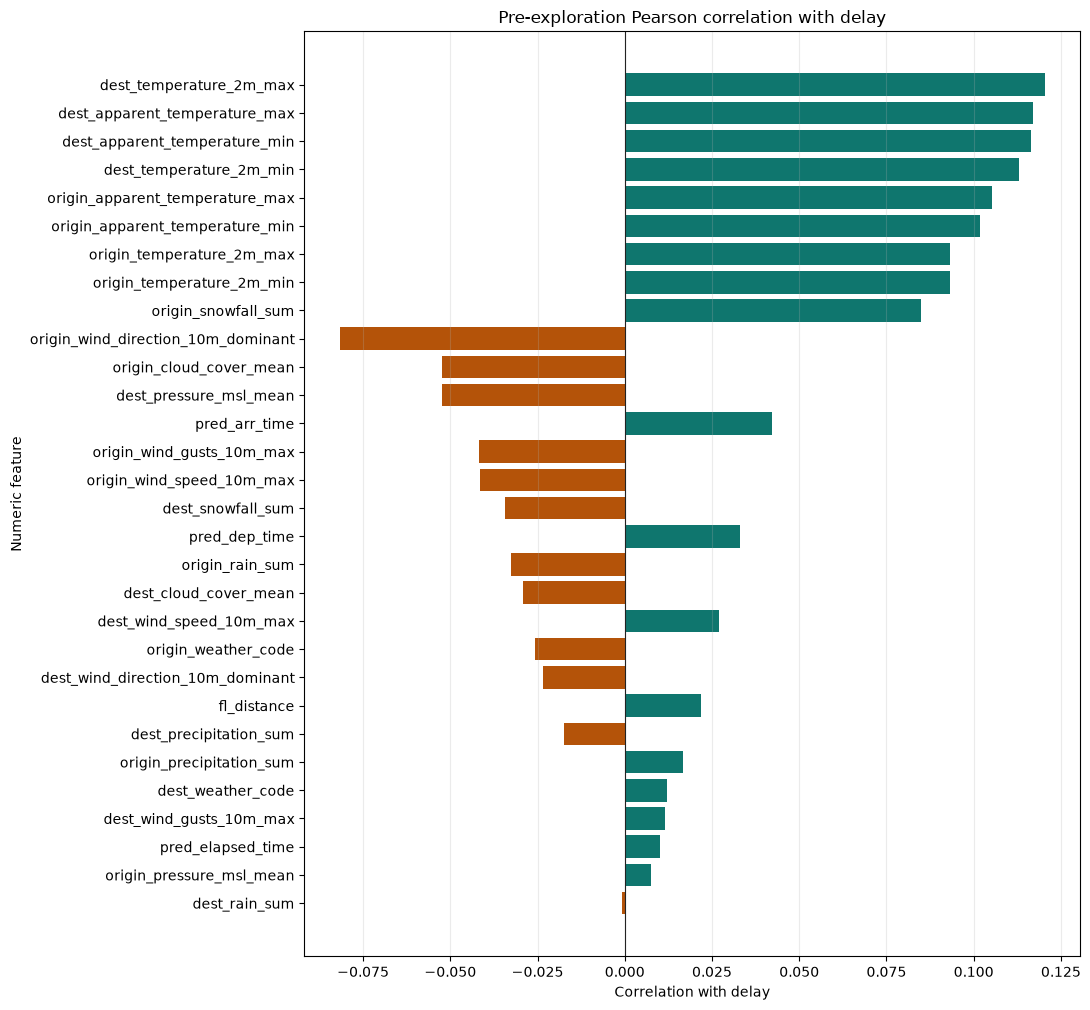

In [20]:
# Correlations

numeric_features = data_df[x_numeric_features + ["delay"]].dropna(axis=0).select_dtypes(include="number")
delay_correlations = (
    numeric_features
    .corr(numeric_only=True)["delay"]
    .drop("delay")
    .dropna()
    .sort_values(key=lambda values: values.abs())
)

fig, ax = plt.subplots(figsize=(11, max(8, 0.34 * len(delay_correlations))))
colors = ["#b45309" if value < 0 else "#0f766e" for value in delay_correlations]

ax.barh(delay_correlations.index, delay_correlations.values, color=colors)
ax.axvline(0, color="#222222", linewidth=0.8)
ax.set_title("Pre-exploration Pearson correlation with delay")
ax.set_xlabel("Correlation with delay")
ax.set_ylabel("Numeric feature")
ax.grid(axis="x", alpha=0.25)

fig.tight_layout()
fig.savefig(FIGURES_PATH/ "correlation_chart.png", dpi=300, bbox_inches="tight")
plt.close(fig)

In [ ]:
# Distribution
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(data_df["delay"].dropna(), bins=range(-60, 301, 10), color="slategray", edgecolor="white")

ax.set_title("Distribution of flight delays")
ax.set_xlabel("Delay (mins)")
ax.set_ylabel("Number of flights")

ax.set_xlim(-10, 151)

fig.tight_layout()
fig.savefig(FIGURES_PATH/ "delay_distribution.png", dpi=300, bbox_inches="tight")
plt.close(fig)

In [ ]:
# Missing values

missing = data_df[x_features + ["delay"]].isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(missing.index, missing.values)

ax.set_title("Missing values in data")
ax.set_xlabel("Fraction missing")
ax.set_ylabel("Feature")

fig.tight_layout()
fig.savefig(FIGURES_PATH/ "missing_values.png", dpi=300, bbox_inches="tight")
plt.close(fig)

### Training
Methods for accuracy improvments:
- Duplicate accurate indicators (shown in correlation img)
- Combine features, for example: snow + wind
- Train many models

In [ ]:
# DummyClassifier Baseline
dummy_strats = ['most_frequent', 'stratified', 'uniform']

test_scores = []
for s in dummy_strats:
    dclf = DummyClassifier(strategy = s, random_state = 0)
        
    dclf.fit(X_train, y_train)
    score = dclf.score(X_test, y_test)
    test_scores.append(score)

# dummy results
ax = sns.stripplot(x=dummy_strats, y=test_scores)
ax.set_xlabel("Dummy strategies")
ax.set_ylabel("Results")
plt.savefig(FIGURES_PATH/'dummy_strats.png')
plt.close()


In [15]:
# Random forest classifier search. Keep this modest enough for a short AWS run.
param_grid = {
    "classifier__n_estimators": [150, 250, 350],
    "classifier__max_depth": [12, 18, 24, None],
    "classifier__min_samples_split": [5, 10, 20],
    "classifier__min_samples_leaf": [2, 5, 10],
    "classifier__max_features": ["sqrt", "log2", 0.5],
    "classifier__bootstrap": [True],
    "classifier__max_samples": [0.7, 0.9],
    "classifier__class_weight": ["balanced", "balanced_subsample"],
}

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), x_categorical_features),
        ("numeric", "passthrough", x_numeric_features),
    ]
)

pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", RandomForestClassifier(n_jobs=1, random_state=1)),
    ]
)

grid_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=24,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=1,
)

grid_search.fit(X_train, y_train)


NameError: name 'X_train' is not defined

In [5]:
preds = grid_search.predict(X_test)
pred_probs = grid_search.predict_proba(X_test)[:, 1]

results = f"""
Run: {dt.now().strftime("%Y-%m-%d -- %H-%M-%S")}
Best CV F1: {grid_search.best_score_:.4f}
Accuracy: {accuracy_score(y_test, preds):.4f}
Precision: {precision_score(y_test, preds, zero_division=0):.4f}
Recall: {recall_score(y_test, preds, zero_division=0):.4f}
F1: {f1_score(y_test, preds, zero_division=0):.4f}
ROC AUC: {roc_auc_score(y_test, pred_probs):.4f}
=== space ===
=== space ===
"""
with open(FIGURES_PATH/ "train_results/best_results.txt", "a") as f:
    try:
        f.write(results)
    except:
        print("Error writing results from train, check terminal")
    finally:
        print(results)

NameError: name 'grid_search' is not defined